In [20]:
import pandas as pandas
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [1]:
import pandas as pd 

df = pd.read_csv("../data/credit_risk_dataset.csv")

In [2]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.info

<bound method DataFrame.info of        person_age  person_income person_home_ownership  person_emp_length  \
0              22          59000                  RENT              123.0   
1              21           9600                   OWN                5.0   
2              25           9600              MORTGAGE                1.0   
3              23          65500                  RENT                4.0   
4              24          54400                  RENT                8.0   
...           ...            ...                   ...                ...   
32576          57          53000              MORTGAGE                1.0   
32577          54         120000              MORTGAGE                4.0   
32578          65          76000                  RENT                3.0   
32579          56         150000              MORTGAGE                5.0   
32580          66          42000                  RENT                2.0   

           loan_intent loan_grade  loan_amn

In [8]:
df.shape

(32581, 12)

In [9]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [10]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [11]:
df.isnull().mean() * 100  

person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
person_emp_length             2.747000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_int_rate                 9.563856
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

<Axes: xlabel='loan_status', ylabel='count'>

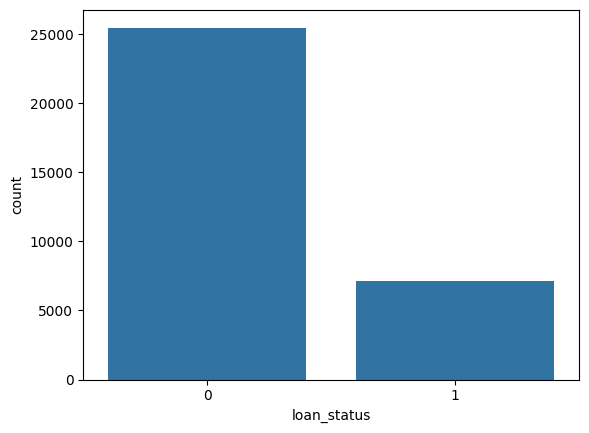

In [15]:
df['loan_status'].value_counts()

sns.countplot(x='loan_status', data=df)

In [16]:
df['loan_status'].value_counts(normalize=True) * 100. # projede hedef değişke loan_status : kredi alıp almadığı yani çok büyük dengeszilik var 

loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

## Outlier Analysis

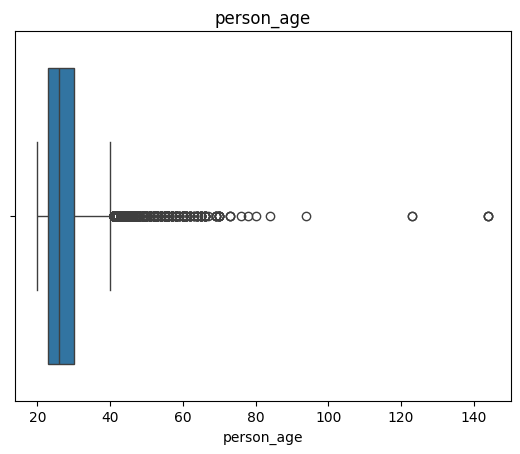

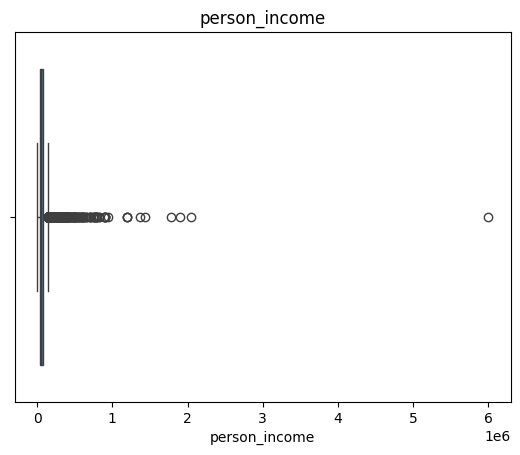

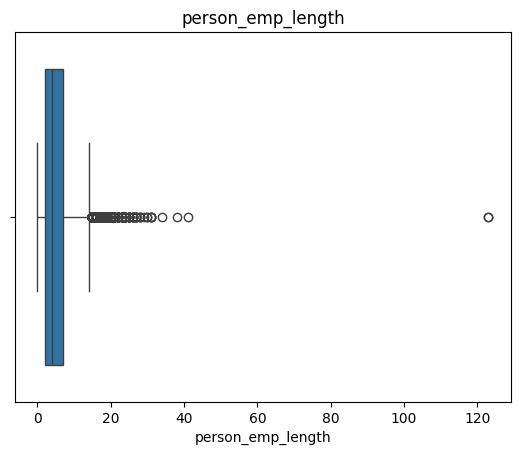

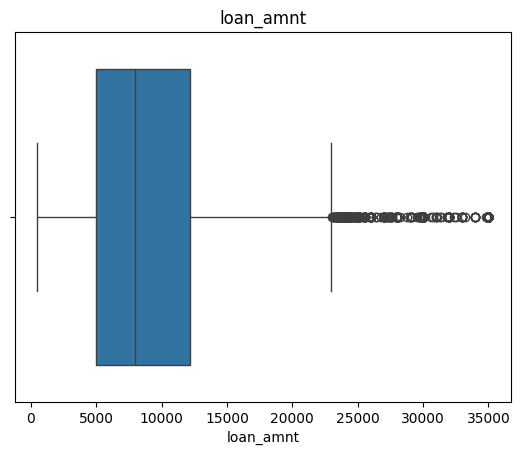

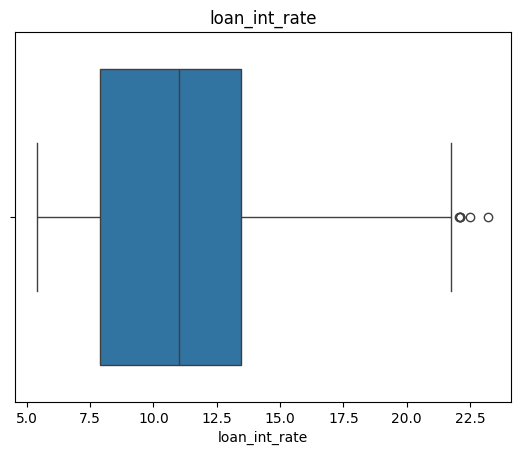

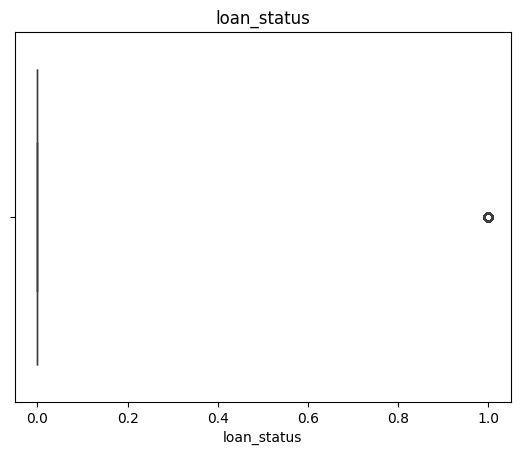

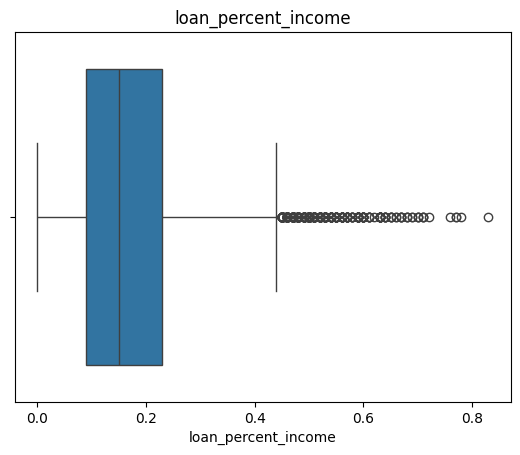

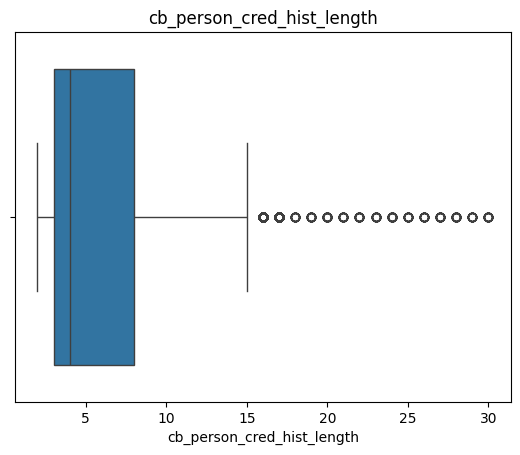

In [21]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].describe()

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [22]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(df[col].value_counts())
    print("---")

person_home_ownership
RENT        16446
MORTGAGE    13444
OWN          2584
OTHER         107
Name: count, dtype: int64
---
loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64
---
loan_grade
A    10777
B    10451
C     6458
D     3626
E      964
F      241
G       64
Name: count, dtype: int64
---
cb_person_default_on_file
N    26836
Y     5745
Name: count, dtype: int64
---


<Axes: >

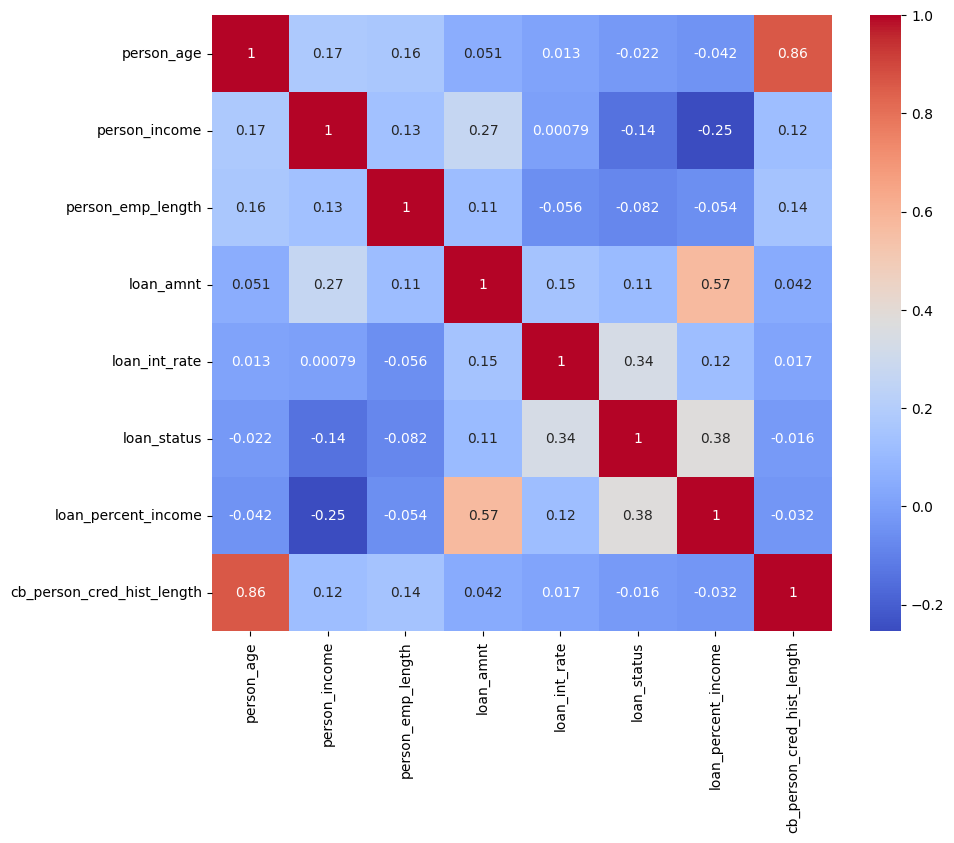

In [23]:
plt.figure(figsize=(10,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')

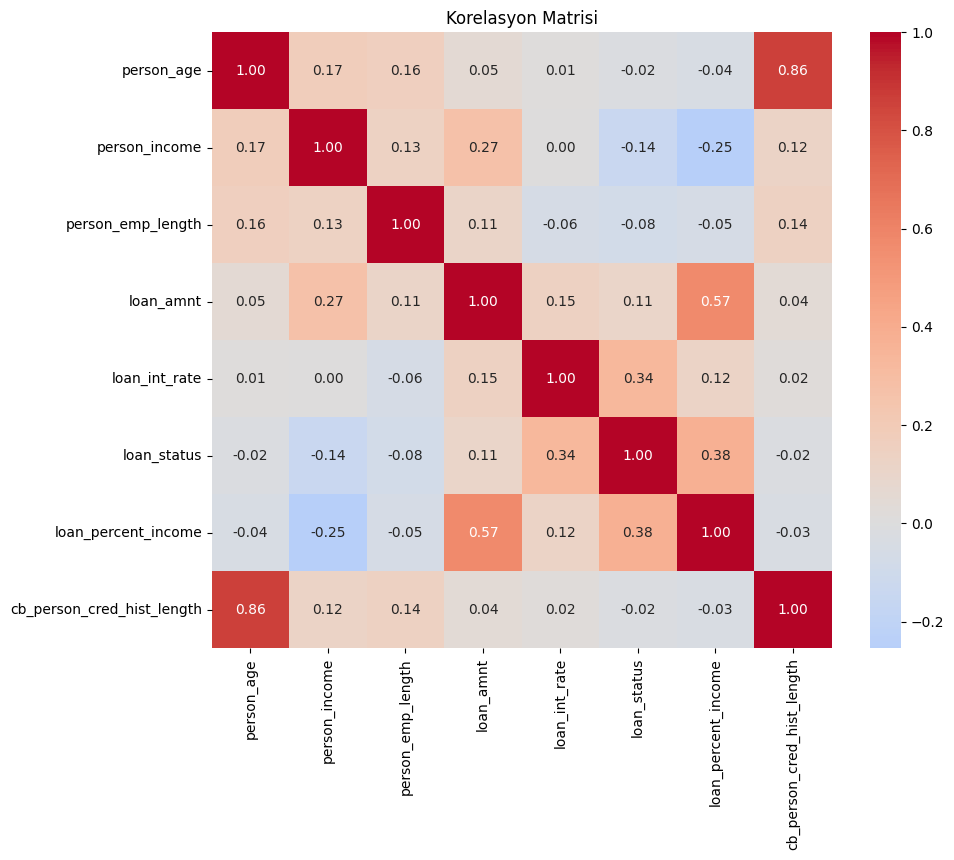

In [24]:
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()   # varsayılan: Pearson

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title("Korelasyon Matrisi")
plt.show()

Correlation Between Debt to Income Ratio and Default Rate: 0.37936646846126365


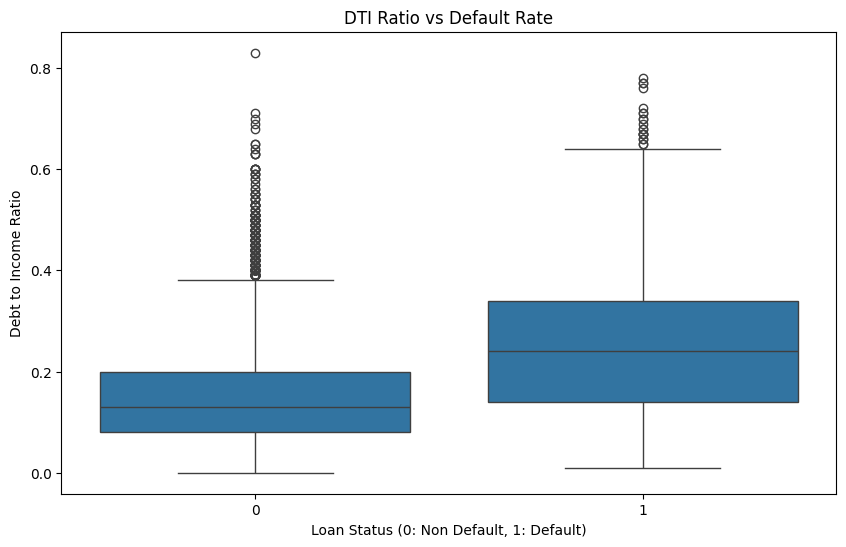

In [25]:
data = df.copy()

data.head()

correlation_df = data[["loan_percent_income","loan_status"]]

correlation = correlation_df["loan_percent_income"].corr(correlation_df["loan_status"])
print(f"Correlation Between Debt to Income Ratio and Default Rate: {correlation}")

plt.figure(figsize=(10,6))
sns.boxplot(x="loan_status", y="loan_percent_income", data=data)
plt.title("DTI Ratio vs Default Rate")
plt.xlabel("Loan Status (0: Non Default, 1: Default)")
plt.ylabel("Debt to Income Ratio")
plt.show()

## Outlier Analysis

In [33]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    print(f"{column}:")
    print(f"  Alt sınır: {lower_bound:.2f}, Üst sınır: {upper_bound:.2f}")
    print(f"  Aykırı değer sayısı: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")
    print()


numeric_cols = ["person_age", "person_income", "person_emp_length",
                 "loan_amnt", "loan_int_rate", "loan_percent_income",
                 "cb_person_cred_hist_length"]

for col in numeric_cols:
    check_outliers(df, col)

person_age:
  Alt sınır: 12.50, Üst sınır: 40.50
  Aykırı değer sayısı: 1494 (4.59%)

person_income:
  Alt sınır: -22550.00, Üst sınır: 140250.00
  Aykırı değer sayısı: 1484 (4.55%)

person_emp_length:
  Alt sınır: -5.50, Üst sınır: 14.50
  Aykırı değer sayısı: 853 (2.62%)

loan_amnt:
  Alt sınır: -5800.00, Üst sınır: 23000.00
  Aykırı değer sayısı: 1689 (5.18%)

loan_int_rate:
  Alt sınır: -0.46, Üst sınır: 21.83
  Aykırı değer sayısı: 6 (0.02%)

loan_percent_income:
  Alt sınır: -0.12, Üst sınır: 0.44
  Aykırı değer sayısı: 651 (2.00%)

cb_person_cred_hist_length:
  Alt sınır: -4.50, Üst sınır: 15.50
  Aykırı değer sayısı: 1142 (3.51%)



In [ ]:
# %4 - % 2 - %4.5 % %5 Fazla olan değerlerde  outlier var 
